In [13]:
%pip install lets-plot

Note: you may need to restart the kernel to use updated packages.


In [12]:
import polars as pl
from pathlib import Path
from lets_plot import *
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

LetsPlot.setup_html(isolated_frame=False)

# In notebooks, __file__ is not defined. Find project root by walking up to "raw_data".
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "raw_data").exists():
	project_root = project_root.parent

DATA_DIR = project_root / "raw_data" / "fsu_donor_data"


NameError: name 'coord' is not defined

In [2]:
base = pl.read_parquet(DATA_DIR / "base_table.parquet")
demographic = pl.read_parquet(DATA_DIR / "demographic.parquet")
education = pl.read_parquet(DATA_DIR / "education.parquet")
board_members = pl.read_parquet(DATA_DIR / "board_members.parquet")
ten_year_donation = pl.read_parquet(DATA_DIR / "ten_year_donation.parquet")
wealth = pl.read_parquet(DATA_DIR / "wealth.parquet")

In [5]:
import pandas as pd

files = ["base_table", "board_members", "demographic", "education", "ten_year_donation", "wealth"]

for f in files:
    df = pd.read_parquet(DATA_DIR / f"{f}.parquet")
    print(f"\n=== {f} | {df.shape} ===")
    print(df.columns.tolist())
    print(df.head(3).to_string())
    print(df.dtypes)
    print(df.isnull().sum())


=== base_table | (706118, 26) ===
['FanID', 'AccountID', 'CRMID', 'state', 'county', 'Region', 'AccountType', 'YearsOfDonating', 'CurrentYearMembershipLevel', 'MostRecentMembershipLevel', 'MostRecentMembershipYear', 'HighestMembershipLevel', 'LowestMembershipLevel', 'PriorYearMembershipLevel', 'TotalLifetimeMembershipDonationDollars', 'LifetimeGivingRank', 'IsAlumni', 'IsSportParticipant', 'PYAnnualFundPledged', 'PYAnnualFundPaid', 'CYAnnualFundPledged', 'CYAnnualFundPaid', 'CurrentYearMembershipPledged', 'CurrentYearMembershipPaid', 'CurrentYearOtherPledged', 'CurrentYearOtherPaid']
   FanID  AccountID     CRMID state      county          Region AccountType  YearsOfDonating CurrentYearMembershipLevel MostRecentMembershipLevel  MostRecentMembershipYear HighestMembershipLevel LowestMembershipLevel PriorYearMembershipLevel  TotalLifetimeMembershipDonationDollars  LifetimeGivingRank IsAlumni IsSportParticipant  PYAnnualFundPledged  PYAnnualFundPaid  CYAnnualFundPledged  CYAnnualFundPaid 

## PROBLEM TO SOLVE: 
I have data of people who enrolled to donate to FSU. Alternatives for predicting:
1) What type of people are less likely to make a payment commitment and don't follow it?
2) How much a person can donnate?
3) How much a person can be willing to donnate?
4) How much a fund group will receive next year? -> classification + regression


In [8]:
ten_year_donation = ten_year_donation.with_columns(
    (
        (pl.col("PaymentAmount") < pl.col("PledgeAmount"))
        | pl.col("PaymentAmount").is_null()
        | (pl.col("PaymentAmount") == 0)
    ).alias("incumplimiento")
)

print(
    ten_year_donation
    .group_by("incumplimiento")
    .len()
    .with_columns((pl.col("len") / pl.col("len").sum()).alias("proportion"))
)

shape: (2, 3)
┌────────────────┬────────┬────────────┐
│ incumplimiento ┆ len    ┆ proportion │
│ ---            ┆ ---    ┆ ---        │
│ bool           ┆ u32    ┆ f64        │
╞════════════════╪════════╪════════════╡
│ true           ┆ 6564   ┆ 0.030489   │
│ false          ┆ 208728 ┆ 0.969511   │
└────────────────┴────────┴────────────┘


In [10]:

print(ten_year_donation['PledgeAmount'].describe())
for q in [0.90, 0.95, 0.99, 0.999]:
	print(f"quantile {q}: {ten_year_donation['PledgeAmount'].quantile(q)}")

shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 215292.0     │
│ null_count ┆ 0.0          │
│ mean       ┆ 2815.725283  │
│ std        ┆ 79817.499889 │
│ min        ┆ 0.0          │
│ 25%        ┆ 70.0         │
│ 50%        ┆ 400.0        │
│ 75%        ┆ 1300.0       │
│ max        ┆ 2.298e7      │
└────────────┴──────────────┘
quantile 0.9: 3500.0
quantile 0.95: 6500.0
quantile 0.99: 24000.0
quantile 0.999: 222700.0


In [12]:
print(ten_year_donation.select(pl.col("DatePledged").drop_nulls().head(10)))
print(ten_year_donation.select(pl.col("Most Recent Payment/Pledge Date").drop_nulls().head(10)))


shape: (10, 1)
┌─────────────────────┐
│ DatePledged         │
│ ---                 │
│ datetime[ns]        │
╞═════════════════════╡
│ 2023-07-21 00:00:00 │
│ 2023-07-21 00:00:00 │
│ 2022-11-08 00:00:00 │
│ 2021-12-16 00:00:00 │
│ 2019-10-11 00:00:00 │
│ 2020-10-10 00:00:00 │
│ 2019-10-10 00:00:00 │
│ 2019-10-11 00:00:00 │
│ 2014-08-27 00:00:00 │
│ 2014-08-27 00:00:00 │
└─────────────────────┘
shape: (10, 1)
┌─────────────────────────────────┐
│ Most Recent Payment/Pledge Dat… │
│ ---                             │
│ datetime[ns]                    │
╞═════════════════════════════════╡
│ 2024-06-21 00:00:00             │
│ 2024-06-21 00:00:00             │
│ 2022-11-08 00:00:00             │
│ 2021-12-16 00:00:00             │
│ 2021-03-04 00:00:00             │
│ 2021-07-07 00:00:00             │
│ 2020-03-30 00:00:00             │
│ 2020-08-25 00:00:00             │
│ 2018-12-24 00:00:00             │
│ 2017-12-06 00:00:00             │
└─────────────────────────────────┘


In [15]:
df = pd.read_csv("C:/ProgramData/MySQL/MySQL Server 8.0/Uploads/ten_year_donation.csv").head(3)
print(df['DatePledged'].tolist())
print(df['Most Recent Payment/Pledge Date'].tolist())

['2023-07-21T00:00:00.000000000', '2023-07-21T00:00:00.000000000', '2022-11-08T00:00:00.000000000']
['2024-06-21T00:00:00.000000000', '2024-06-21T00:00:00.000000000', '2022-11-08T00:00:00.000000000']


In [17]:
import pandas as pd
df = pd.read_parquet(DATA_DIR /"ten_year_donation.parquet")
df_grouped = df.groupby('FanID').agg(
    total_pledged=('PledgeAmount', 'sum'),
    total_paid=('PaymentAmount', 'sum')
).query('total_pledged > 0')
df_grouped['reliability'] = df_grouped['total_paid'] / df_grouped['total_pledged']
print(df_grouped['reliability'].describe())
print(df_grouped['reliability'].quantile([0.25, 0.50, 0.75, 0.90]))

count    38537.000000
mean         1.118811
std          1.408469
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000942
max        143.857143
Name: reliability, dtype: float64
0.25    1.000000
0.50    1.000000
0.75    1.000942
0.90    1.283019
Name: reliability, dtype: float64


In [18]:
df = pd.read_parquet(DATA_DIR / "education.parquet")
print(df['College'].nunique())
print(df['College'].value_counts().head(10))

19
College
Business                                 22782
Education, Health, and Human Sciences    14443
Social Sciences                          11837
Arts & Sciences                          11578
Communication & Information               4475
Criminology & Criminal Justice            4331
College of Law                            2436
Undergraduate Studies                     2384
Social Work                               1618
Engineering                               1466
Name: count, dtype: int64


In [19]:
import pandas as pd
df = pd.read_parquet(DATA_DIR / "ten_year_donation.parquet")
donors_with_history = df['FanID'].nunique()
df_base = pd.read_parquet(DATA_DIR / "base_table.parquet")
total_donors = df_base['FanID'].nunique()
print(f"Con historial: {donors_with_history}")
print(f"Total: {total_donors}")
print(f"Sin historial: {total_donors - donors_with_history}")

Con historial: 45806
Total: 706118
Sin historial: 660312


In [20]:
import pandas as pd
df_base = pd.read_parquet(DATA_DIR / "base_table.parquet")
df_donations = pd.read_parquet(DATA_DIR / "ten_year_donation.parquet")

donors = df_donations['FanID'].unique()
no_history = df_base[~df_base['FanID'].isin(donors)]

print(no_history['IsAlumni'].value_counts(normalize=True))
print(no_history['AccountType'].value_counts())
print(no_history['YearsOfDonating'].describe())

IsAlumni
N    0.931325
Y    0.068675
Name: proportion, dtype: float64
AccountType
Individual      656477
Guest             2021
Organization      1814
Name: count, dtype: int64
count    660312.000000
mean          0.137241
std           0.947208
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          25.000000
Name: YearsOfDonating, dtype: float64


In [21]:
import pandas as pd
df_base = pd.read_parquet(DATA_DIR / "base_table.parquet")
df_donations = pd.read_parquet(DATA_DIR / "ten_year_donation.parquet")

no_history_ids = df_base[~df_base['FanID'].isin(df_donations['FanID'])]['FanID']
future_pledges = df_donations[
    (df_donations['FanID'].isin(no_history_ids)) & 
    (df_donations['DriveYear'] >= 2025)
]
print(future_pledges.shape)
print(future_pledges['DriveYear'].value_counts())
print(future_pledges[['FanID','DriveYear','PledgeAmount','PaymentAmount']].head(10))

(0, 9)
Series([], Name: count, dtype: int64)
Empty DataFrame
Columns: [FanID, DriveYear, PledgeAmount, PaymentAmount]
Index: []


In [22]:
import pandas as pd
df = pd.read_parquet( DATA_DIR / "board_members.parquet")
print(df['StartDate'].dropna().head(5).tolist())
print(df['EndDate'].dropna().head(5).tolist())

[Timestamp('1989-01-01 00:00:00'), Timestamp('1999-01-01 00:00:00'), Timestamp('2002-01-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2019-01-30 00:00:00')]
[Timestamp('1991-12-31 00:00:00'), Timestamp('2001-12-31 00:00:00'), Timestamp('2004-12-31 00:00:00'), Timestamp('2020-02-18 00:00:00'), Timestamp('2021-06-30 00:00:00')]


In [24]:
import pandas as pd
df = pd.read_parquet(DATA_DIR / "board_members.parquet")
print(df['Current'].value_counts(dropna=False))
print(df['Current'].dtype)

Current
False    660
True     195
Name: count, dtype: int64
bool


In [25]:
import pandas as pd

df = pd.read_parquet(DATA_DIR / "board_members.parquet")
df['StartDate'] = pd.to_datetime(df['StartDate']).dt.strftime('%Y-%m-%d')
df['EndDate'] = pd.to_datetime(df['EndDate']).dt.strftime('%Y-%m-%d')
df['Current'] = df['Current'].astype(int)
df.to_csv("C:/ProgramData/MySQL/MySQL Server 8.0/Uploads/board_members.csv", index=False)

# EMPEZAR CON DATOS YA FUSIONADOS

In [1]:
import numpy as np
import pandas as pd
columns = ['FanID', 'DriveYear', 'Num_group_donating', 'Lag1_Pledge', 'Lag1_null',
           'TotalPledgeAnual', 'next_year_donation', 'MaxYear', 'MinYear', 'YearsCount',
           'Avg_pledges_3years', 'Avg_pct_increase_5years', 'insufficient_history',
           'EducationStatus', 'Degree', 'College', 'was_board_member', 'CurrentFlag',
           'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction',
           'Properties_null', 'Age', 'state', 'YearsOfDonating', 'HighestMembershipLevel',
           'MostRecentMembershipLevel', 'CYAnnualFundPledged' , 'CYAnnualFundPaid', 'IsAlumni']

df = pd.read_csv('modeling_table.csv', header=None, names=columns)
print(df.head())
print(df.describe())
print(df.isnull().sum()[df.isnull().sum() > 0])

print(df.shape)

   FanID  DriveYear  Num_group_donating  Lag1_Pledge  Lag1_null  \
0     13       2016                   1          0.0          1   
1     13       2017                   3       3500.0          0   
2     13       2018                   3       8300.0          0   
3     13       2019                   3       8050.0          0   
4     13       2020                   2       8050.0          0   

   TotalPledgeAnual  next_year_donation  MaxYear  MinYear  YearsCount  ...  \
0            3500.0              8300.0     2024     2016           9  ...   
1            8300.0              8050.0     2024     2016           9  ...   
2            8050.0              8050.0     2024     2016           9  ...   
3            8050.0              5900.0     2024     2016           9  ...   
4            5900.0              8300.0     2024     2016           9  ...   

   IWave_AnnualCapacityTargetProduction  Properties_null  Age state  \
0                                   0.0                1 

In [3]:
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(116890, 30)
state                          122
HighestMembershipLevel       18569
MostRecentMembershipLevel    23864
dtype: int64


## Clasificar 
Decisiones de preprocesamiento confirmadas
Target: log(next_year_donation) → revertir con exp() al evaluar
Numéricas — sin transformación: Num_group_donating, Lag1_Pledge, TotalPledgeAnual, YearsCount, Avg_pledges_3years, Avg_pct_increase_5years, YearsOfDonating, Age, IWave_Properties, IWave_PropertiesValue, IWave_AnnualCapacityTargetProduction
Booleanas — directo: insufficient_history, Lag1_null, Properties_null, was_board_member, CurrentFlag, IsAlumni
Ordinales: HighestMembershipLevel, MostRecentMembershipLevel → Legacy Chief=7 hasta Spirit=1, NULL=0. Degree → función Python por nivel
OneHotEncoding: EducationStatus, College
Regiones: state → is_florida + 4 regiones
Train/Val/Holdout: 2014-2023 / 2024 / 2025

In [2]:
# Feature engineering and preprocessing
df = df[df['next_year_donation']>0]
df['next_year_donation'] = np.log1p(df['next_year_donation'])
# 1. Membership level mapping (10=Legacy Chief down to 1=Spirit, 0=NULL)
membership_mapping = {
    'Legacy Chief': 10,
    'Platinum Chief': 9,
    'Golden Chief': 8,
    'Silver Chief': 7,
    'Tomahawk': 6,
    'Warrior': 5,
    'Renegade': 4,
    'Brave': 3,
    'Iron Arrow': 2,
    'Spirit': 1,
    np.nan: 0,
    "":0,
}

# 2. Create a copy for preprocessing
df_processed = df.copy()

# 3. Fix Age column (currently object type)
df_processed['Age'] = pd.to_numeric(df_processed['Age'], errors='coerce')

# 4. Apply Degree classification
def classify_degree(degree):
    if pd.isna(degree): return 0
    degree = degree.lower()
    if 'doctor' in degree or 'juris' in degree or 'ph.d' in degree: return 4
    if 'master' in degree or 'mba' in degree: return 3
    if 'bachelor' in degree: return 2
    if 'associate' in degree: return 1
    return 0
df_processed['Degree_encoded'] = df_processed['Degree'].apply(classify_degree)

# 5. Encode membership levels
df_processed['HighestMembershipLevel_encoded'] = df_processed['HighestMembershipLevel'].map(membership_mapping)
df_processed['MostRecentMembershipLevel_encoded'] = df_processed['MostRecentMembershipLevel'].map(membership_mapping)
# 6. One-hot encode
education_dummies = pd.get_dummies(df_processed[['EducationStatus', 'College']], prefix=['EducationStatus', 'College'], drop_first=False)
df_processed = pd.concat([df_processed, education_dummies], axis=1)

# 7. Create Age_null indicator BEFORE imputation
df_processed['Age_null'] = df_processed['Age'].isnull().astype(int)

# 8. Regional encoding from state
df_processed['is_florida'] = (df_processed['state'] == 'FL').astype(int)

# Northeast, Southeast, Midwest, West regions
northeast = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA']
southeast = ['DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'AL', 'MS', 'LA', 'AR', 'TN', 'KY','TX']
midwest = ['OH', 'IN', 'IL', 'MI', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']
west = ['MT', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'CA', 'OR', 'WA', 'ID', 'AK', 'HI']

df_processed['region_northeast'] = df_processed['state'].isin(northeast).astype(int)
df_processed['region_southeast'] = df_processed['state'].isin(southeast).astype(int)
df_processed['region_midwest'] = df_processed['state'].isin(midwest).astype(int)
df_processed['region_west'] = df_processed['state'].isin(west).astype(int)

# 9. Convert boolean columns
df_processed['insufficient_history'] = df_processed['insufficient_history'].astype(int)
df_processed['Lag1_null'] = df_processed['Lag1_null'].astype(int)
df_processed['Properties_null'] = df_processed['Properties_null'].astype(int)
df_processed['was_board_member'] = df_processed['was_board_member'].astype(int)
df_processed['CurrentFlag'] = df_processed['CurrentFlag'].astype(int)
df_processed['IsAlumni'] = (df_processed['IsAlumni'] == 'Y').astype(int)

# 10. Split data by DriveYear
train_mask = (df_processed['DriveYear'] >= 2014) & (df_processed['DriveYear'] <= 2023)
val_mask = df_processed['DriveYear'] == 2024
test_mask = df_processed['DriveYear'] == 2025

X_train = df_processed[train_mask].copy()
X_val = df_processed[val_mask].copy()
X_test = df_processed[test_mask].copy()

y_train = X_train['next_year_donation']
y_val = X_val['next_year_donation']
y_test = X_test['next_year_donation']

# Select features for modeling
numeric_features = ['Num_group_donating', 'Lag1_Pledge',            'TotalPledgeAnual', 'YearsCount', 
                    'Avg_pledges_3years', 'Avg_pct_increase_5years', 'YearsOfDonating', 'Age',
                    'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction','CYAnnualFundPledged' , 'CYAnnualFundPaid']

boolean_features = ['insufficient_history', 'Lag1_null', 'Properties_null', 'was_board_member', 
                    'CurrentFlag', 'IsAlumni', 'Age_null']

ordinal_features = ['HighestMembershipLevel_encoded', 'MostRecentMembershipLevel_encoded', 'Degree_encoded']

education_features = [col for col in df_processed.columns if col.startswith('EducationStatus_')]
college_features = [col for col in df_processed.columns if col.startswith('College_')]
region_features = ['is_florida', 'region_northeast', 'region_southeast', 'region_midwest', 'region_west']

all_features = numeric_features + boolean_features + ordinal_features + education_features + college_features + region_features

# Calculate Age median BEFORE any imputation
age_median = X_train['Age'].median()

# Select features and handle Age imputation consistently across all sets
X_train = X_train[all_features]
X_train['Age'] = X_train['Age'].fillna(age_median)

X_val = X_val[all_features]
X_val['Age'] = X_val['Age'].fillna(age_median)

X_test = X_test[all_features]
X_test['Age'] = X_test['Age'].fillna(age_median)

print(f"Train set: {X_train.shape}")
print(f"Val set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTotal features: {len(all_features)}")
print(f"Missing values in train:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")


Train set: (94220, 51)
Val set: (11558, 51)
Test set: (1173, 51)

Total features: 51
Missing values in train:
Series([], dtype: int64)


In [65]:
# Paso 1 - valor crudo
df_raw = pd.read_csv('modeling_table.csv', header=None, names=columns)
print("Crudo:", df_raw['next_year_donation'].median())

# Paso 2 - después de filtrar y log1p
df_raw = df_raw[df_raw['next_year_donation'] > 0]
df_raw['next_year_donation'] = np.log1p(df_raw['next_year_donation'])
print("Después de log1p:", df_raw['next_year_donation'].median())

# Paso 3 - después de expm1
print("Después de expm1:", np.expm1(df_raw['next_year_donation']).median())

Crudo: 650.0
Después de log1p: 6.493753839851686
Después de expm1: 659.9999999999998


# LINEAR REGRESSION MODEL

In [69]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Entrenar modelo Ridge
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

# Evaluar en train/val/test
for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    y_pred = ridge_reg.predict(X_split)
    y_pred_original = np.expm1(y_pred)
    y_true_original = np.expm1(y_split)
    rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae = np.mean(np.abs(y_true_original - y_pred_original))
    r2 = r2_score(y_true_original, y_pred_original)
    print(f"{split_name} -> RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | R²: {r2:.4f}")

Train -> RMSE: $30,324,341,173,744,705,536 | MAE: $98,791,928,604,512,272 | R²: -16676992771162795570442027401216.0000
Validation -> RMSE: $65,418,925 | MAE: $618,058 | R²: -36371602.9092
Test -> RMSE: $21,105,830 | MAE: $760,095 | R²: -9215331.3501


c:\Users\alexa\miniconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.10925e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


# XGBOOST MODEL

In [3]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

base_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2],
}

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

xgb_reg = random_search.best_estimator_

# Evaluación en train/val/test
for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    y_pred = xgb_reg.predict(X_split)
    y_pred_original = np.expm1(y_pred)
    y_true_original = np.expm1(y_split.values)
    rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae = np.mean(np.abs(y_true_original - y_pred_original))
    r2 = r2_score(y_true_original, y_pred_original)
    print(f"{split_name} -> RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | R²: {r2:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 0.5479471537037018
Train -> RMSE: $4,427 | MAE: $588 | R²: 0.6446
Validation -> RMSE: $7,834 | MAE: $1,145 | R²: 0.4785
Test -> RMSE: $8,500 | MAE: $2,373 | R²: -0.4945


In [76]:
print(y_test.describe())
print(np.expm1(y_test).describe())

count    1173.000000
mean        5.870326
std         2.724133
min         0.262364
25%         4.262680
50%         6.398595
75%         8.146419
max        11.350418
Name: next_year_donation, dtype: float64
count     1173.000000
mean      3064.046743
std       6955.560692
min          0.300000
25%         70.000000
50%        600.000000
75%       3450.000000
max      85000.000000
Name: next_year_donation, dtype: float64


In [14]:
# Feature importances del modelo XGBoost
fi = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgb_reg.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()

print("Top 20 features por importancia:")
print(fi.head(20).to_string(index=False))

# display(fi)

# Gráfico (top 20)
# top_n = 20
# plot_df = fi.head(top_n).iloc[::-1]  # invertido para barra horizontal

# ggplot(plot_df, aes(x="importance", y="feature")) + \
#     geom_bar(stat="identity") + \
#     ggtitle(f"Top {top_n} Feature Importances - XGBoost") + \
#     xlab("Importance") + \
#     ylab("Feature")

Top 20 features por importancia:
                           feature  importance  importance_pct
                  TotalPledgeAnual    0.457902       45.790222
    HighestMembershipLevel_encoded    0.215608       21.560785
                        College_\N    0.030594        3.059441
                Avg_pledges_3years    0.019275        1.927535
              insufficient_history    0.017967        1.796732
 MostRecentMembershipLevel_encoded    0.013648        1.364784
                EducationStatus_\N    0.011586        1.158614
            College_College of Law    0.009762        0.976198
                        YearsCount    0.009190        0.919027
               CYAnnualFundPledged    0.008428        0.842806
                  CYAnnualFundPaid    0.007971        0.797085
                       Lag1_Pledge    0.007135        0.713461
                          IsAlumni    0.006999        0.699912
                    region_midwest    0.006944        0.694358
                      

In [4]:
y_true_val = np.expm1(y_val.values)
y_naive_val = X_val['TotalPledgeAnual'].to_numpy(dtype=float)  # Ya está en escala original

# Limpieza defensiva por si hubiera NaN/inf
valid = np.isfinite(y_true_val) & np.isfinite(y_naive_val)
y_true_val = y_true_val[valid]
y_naive_val = y_naive_val[valid]

rmse_naive = np.sqrt(mean_squared_error(y_true_val, y_naive_val))
mae_naive = np.mean(np.abs(y_true_val - y_naive_val))
print(f"Naive -> RMSE: ${rmse_naive:,.0f} | MAE: ${mae_naive:,.0f}")

Naive -> RMSE: $7,727 | MAE: $1,101


In [5]:
val_results = pd.DataFrame({
    'y_true': np.expm1(y_val.values),
    'y_pred': np.expm1(xgb_reg.predict(X_val)),
    'y_naive': np.expm1(X_val['TotalPledgeAnual'].values)
})
val_results['error_xgb'] = np.abs(val_results['y_true'] - val_results['y_pred'])
val_results['error_naive'] = np.abs(val_results['y_true'] - val_results['y_naive'])
val_results['xgb_wins'] = val_results['error_xgb'] < val_results['error_naive']
print(val_results['xgb_wins'].value_counts(normalize=True))
print("\nCuando XGBoost gana:")
print(val_results[val_results['xgb_wins']]['y_true'].describe())
print("\nCuando naive gana:")
print(val_results[~val_results['xgb_wins']]['y_true'].describe())

xgb_wins
True     0.999567
False    0.000433
Name: proportion, dtype: float64

Cuando XGBoost gana:
count     11553.000000
mean       3009.582160
std       10849.988723
min           2.000000
25%         160.000000
50%         669.500000
75%        3250.000000
max      791930.000000
Name: y_true, dtype: float64

Cuando naive gana:
count       5.000000
mean      390.750000
std       517.825683
min        70.000000
25%       125.000000
50%       128.750000
75%       330.000000
max      1300.000000
Name: y_true, dtype: float64


C:\Users\alexa\AppData\Local\Temp\ipykernel_15340\1522597689.py:4: RuntimeWarning: overflow encountered in expm1
  'y_naive': np.expm1(X_val['TotalPledgeAnual'].values)


In [6]:
print(list(xgb_reg.feature_names_in_))
print(len(xgb_reg.feature_names_in_))

[np.str_('Num_group_donating'), np.str_('Lag1_Pledge'), np.str_('TotalPledgeAnual'), np.str_('YearsCount'), np.str_('Avg_pledges_3years'), np.str_('Avg_pct_increase_5years'), np.str_('YearsOfDonating'), np.str_('Age'), np.str_('IWave_Properties'), np.str_('IWave_PropertiesValue'), np.str_('IWave_AnnualCapacityTargetProduction'), np.str_('CYAnnualFundPledged'), np.str_('CYAnnualFundPaid'), np.str_('insufficient_history'), np.str_('Lag1_null'), np.str_('Properties_null'), np.str_('was_board_member'), np.str_('CurrentFlag'), np.str_('IsAlumni'), np.str_('Age_null'), np.str_('HighestMembershipLevel_encoded'), np.str_('MostRecentMembershipLevel_encoded'), np.str_('Degree_encoded'), np.str_('EducationStatus_Currently attending'), np.str_('EducationStatus_Graduated'), np.str_('EducationStatus_Incomplete'), np.str_('EducationStatus_\\N'), np.str_('College_Applied Studies'), np.str_('College_Arts & Sciences'), np.str_('College_Business'), np.str_('College_College of Law'), np.str_('College_Coll

# XGBOOST WITHOUT TOTALPLEDGE AMOUNT

In [19]:
columns = ['FanID', 'DriveYear', 'Num_group_donating', 'Lag1_Pledge', 'Lag1_null',
           'TotalPledgeAnual', 'next_year_donation', 'MaxYear', 'MinYear', 'YearsCount',
           'Avg_pledges_3years', 'Avg_pct_increase_5years', 'insufficient_history',
           'EducationStatus', 'Degree', 'College', 'was_board_member', 'CurrentFlag',
           'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction',
           'Properties_null', 'Age', 'state', 'YearsOfDonating', 'HighestMembershipLevel',
           'MostRecentMembershipLevel', 'CYAnnualFundPledged' , 'CYAnnualFundPaid', 'IsAlumni']

df = pd.read_csv('modeling_table.csv', header=None, names=columns)

In [20]:
# Feature engineering and preprocessing
df = df[df['next_year_donation']>0]
df['next_year_donation'] = np.log1p(df['next_year_donation'])
# 1. Membership level mapping (10=Legacy Chief down to 1=Spirit, 0=NULL)
membership_mapping = {
    'Legacy Chief': 10,
    'Platinum Chief': 9,
    'Golden Chief': 8,
    'Silver Chief': 7,
    'Tomahawk': 6,
    'Warrior': 5,
    'Renegade': 4,
    'Brave': 3,
    'Iron Arrow': 2,
    'Spirit': 1,
    np.nan: 0,
    "":0,
}

# 2. Create a copy for preprocessing
df_processed = df.copy()

# 3. Fix Age column (currently object type)
df_processed['Age'] = pd.to_numeric(df_processed['Age'], errors='coerce')

# 4. Apply Degree classification
def classify_degree(degree):
    if pd.isna(degree): return 0
    degree = degree.lower()
    if 'doctor' in degree or 'juris' in degree or 'ph.d' in degree: return 4
    if 'master' in degree or 'mba' in degree: return 3
    if 'bachelor' in degree: return 2
    if 'associate' in degree: return 1
    return 0
df_processed['Degree_encoded'] = df_processed['Degree'].apply(classify_degree)

# 5. Encode membership levels
df_processed['HighestMembershipLevel_encoded'] = df_processed['HighestMembershipLevel'].map(membership_mapping)
df_processed['MostRecentMembershipLevel_encoded'] = df_processed['MostRecentMembershipLevel'].map(membership_mapping)
# 6. One-hot encode
education_dummies = pd.get_dummies(df_processed[['EducationStatus', 'College']], prefix=['EducationStatus', 'College'], drop_first=False)
df_processed = pd.concat([df_processed, education_dummies], axis=1)

# 7. Create Age_null indicator BEFORE imputation
df_processed['Age_null'] = df_processed['Age'].isnull().astype(int)

# 8. Regional encoding from state
df_processed['is_florida'] = (df_processed['state'] == 'FL').astype(int)

# Northeast, Southeast, Midwest, West regions
northeast = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA']
southeast = ['DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'AL', 'MS', 'LA', 'AR', 'TN', 'KY','TX']
midwest = ['OH', 'IN', 'IL', 'MI', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']
west = ['MT', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'CA', 'OR', 'WA', 'ID', 'AK', 'HI']

df_processed['region_northeast'] = df_processed['state'].isin(northeast).astype(int)
df_processed['region_southeast'] = df_processed['state'].isin(southeast).astype(int)
df_processed['region_midwest'] = df_processed['state'].isin(midwest).astype(int)
df_processed['region_west'] = df_processed['state'].isin(west).astype(int)

# 9. Convert boolean columns
df_processed['insufficient_history'] = df_processed['insufficient_history'].astype(int)
df_processed['Lag1_null'] = df_processed['Lag1_null'].astype(int)
df_processed['Properties_null'] = df_processed['Properties_null'].astype(int)
df_processed['was_board_member'] = df_processed['was_board_member'].astype(int)
df_processed['CurrentFlag'] = df_processed['CurrentFlag'].astype(int)
df_processed['IsAlumni'] = (df_processed['IsAlumni'] == 'Y').astype(int)

# 10. Split data by DriveYear
train_mask = (df_processed['DriveYear'] >= 2014) & (df_processed['DriveYear'] <= 2023)
val_mask = df_processed['DriveYear'] == 2024
test_mask = df_processed['DriveYear'] == 2025

X_train = df_processed[train_mask].copy()
X_val = df_processed[val_mask].copy()
X_test = df_processed[test_mask].copy()

y_train = X_train['next_year_donation']
y_val = X_val['next_year_donation']
y_test = X_test['next_year_donation']

# Select features for modeling
numeric_features = ['Num_group_donating', 'Lag1_Pledge', 'YearsCount', 
                    'Avg_pledges_3years', 'Avg_pct_increase_5years', 'YearsOfDonating', 'Age',
                    'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction','CYAnnualFundPledged' , 'CYAnnualFundPaid']

boolean_features = ['insufficient_history', 'Lag1_null', 'Properties_null', 'was_board_member', 
                    'CurrentFlag', 'IsAlumni', 'Age_null']

ordinal_features = ['HighestMembershipLevel_encoded', 'MostRecentMembershipLevel_encoded', 'Degree_encoded']

education_features = [col for col in df_processed.columns if col.startswith('EducationStatus_')]
college_features = [col for col in df_processed.columns if col.startswith('College_')]
region_features = ['is_florida', 'region_northeast', 'region_southeast', 'region_midwest', 'region_west']

all_features = numeric_features + boolean_features + ordinal_features + education_features + college_features + region_features

# Calculate Age median BEFORE any imputation
age_median = X_train['Age'].median()

# Select features and handle Age imputation consistently across all sets
X_train = X_train[all_features]
X_train['Age'] = X_train['Age'].fillna(age_median)

X_val = X_val[all_features]
X_val['Age'] = X_val['Age'].fillna(age_median)

X_test = X_test[all_features]
X_test['Age'] = X_test['Age'].fillna(age_median)

print(f"Train set: {X_train.shape}")
print(f"Val set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTotal features: {len(all_features)}")
print(f"Missing values in train:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")


Train set: (94220, 50)
Val set: (11558, 50)
Test set: (1173, 50)

Total features: 50
Missing values in train:
Series([], dtype: int64)


In [21]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

base_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2],
}

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

xgb_reg = random_search.best_estimator_

# Evaluación en train/val/test
for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    y_pred = xgb_reg.predict(X_split)
    y_pred_original = np.expm1(y_pred)
    y_true_original = np.expm1(y_split.values)
    rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae = np.mean(np.abs(y_true_original - y_pred_original))
    r2 = r2_score(y_true_original, y_pred_original)
    print(f"{split_name} -> RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | R²: {r2:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 0.6463190374302076
Train -> RMSE: $4,696 | MAE: $714 | R²: 0.6000
Validation -> RMSE: $8,267 | MAE: $1,256 | R²: 0.4192
Test -> RMSE: $8,308 | MAE: $2,506 | R²: -0.4280


In [22]:
fi = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgb_reg.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fi["importance_pct"] = 100 * fi["importance"] / fi["importance"].sum()

print("Top 20 features por importancia:")
print(fi.head(20).to_string(index=False))

Top 20 features por importancia:
                                      feature  importance  importance_pct
               HighestMembershipLevel_encoded    0.268400       26.840015
                           Avg_pledges_3years    0.218761       21.876072
                                  Lag1_Pledge    0.086982        8.698179
                         insufficient_history    0.049626        4.962614
                                   College_\N    0.038027        3.802723
                              Properties_null    0.037256        3.725583
                                    Lag1_null    0.030932        3.093164
                      Avg_pct_increase_5years    0.014267        1.426685
            MostRecentMembershipLevel_encoded    0.012991        1.299106
                           EducationStatus_\N    0.012198        1.219797
                             was_board_member    0.011375        1.137466
                           Num_group_donating    0.010586        1.058588
     

# XGBOOST ONLY TOTALPLEDGE

In [23]:
columns = ['FanID', 'DriveYear', 'Num_group_donating', 'Lag1_Pledge', 'Lag1_null',
           'TotalPledgeAnual', 'next_year_donation', 'MaxYear', 'MinYear', 'YearsCount',
           'Avg_pledges_3years', 'Avg_pct_increase_5years', 'insufficient_history',
           'EducationStatus', 'Degree', 'College', 'was_board_member', 'CurrentFlag',
           'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction',
           'Properties_null', 'Age', 'state', 'YearsOfDonating', 'HighestMembershipLevel',
           'MostRecentMembershipLevel', 'CYAnnualFundPledged' , 'CYAnnualFundPaid', 'IsAlumni']

df = pd.read_csv('modeling_table.csv', header=None, names=columns)

In [25]:
train_mask = (df_processed['DriveYear'] >= 2014) & (df_processed['DriveYear'] <= 2023)
val_mask = df_processed['DriveYear'] == 2024
test_mask = df_processed['DriveYear'] == 2025

X_train = df_processed[train_mask].copy()
X_val = df_processed[val_mask].copy()
X_test = df_processed[test_mask].copy()

y_train = X_train['next_year_donation']
y_val = X_val['next_year_donation']
y_test = X_test['next_year_donation']


X_train = X_train['TotalPledgeAnual'].to_frame()  # Solo para este ejemplo, usaré una sola característica

X_val = X_val['TotalPledgeAnual'].to_frame()

X_test = X_test['TotalPledgeAnual'].to_frame()


In [26]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

base_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2],
}

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

xgb_reg = random_search.best_estimator_

# Evaluación en train/val/test
for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test),
]:
    y_pred = xgb_reg.predict(X_split)
    y_pred_original = np.expm1(y_pred)
    y_true_original = np.expm1(y_split.values)
    rmse = np.sqrt(mean_squared_error(y_true_original, y_pred_original))
    mae = np.mean(np.abs(y_true_original - y_pred_original))
    r2 = r2_score(y_true_original, y_pred_original)
    print(f"{split_name} -> RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | R²: {r2:.4f}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV RMSE: 0.6910622654824855
Train -> RMSE: $5,350 | MAE: $766 | R²: 0.4809
Validation -> RMSE: $8,149 | MAE: $1,242 | R²: 0.4356
Test -> RMSE: $6,233 | MAE: $2,114 | R²: 0.1963


In [3]:
import pandas as pd
import numpy as np

# Volver a la tabla de donaciones original
ten_year_donation = pd.read_csv('ten_year_donation.csv')

# Asegurar tipos numéricos
ten_year_donation["PledgeAmount"] = pd.to_numeric(ten_year_donation["PledgeAmount"], errors="coerce").fillna(0)
ten_year_donation["PaymentAmount"] = pd.to_numeric(ten_year_donation["PaymentAmount"], errors="coerce").fillna(0)

# Tomar solo los últimos 10 años disponibles en el dataset
max_year = 2025
min_year = max_year - 9
td_10y = ten_year_donation[ten_year_donation["DriveYear"].between(min_year, max_year)].copy()

# Agregar por persona y año (por si hay varias filas en el mismo año)
fan_year = (
    td_10y.groupby(["FanID", "DriveYear"], as_index=False)
    .agg(
        PledgeAmount=("PledgeAmount", "sum"),
        PaymentAmount=("PaymentAmount", "sum")
    )
)

# Filtrar años donde hubo compromiso real
fan_year = fan_year[fan_year["PledgeAmount"] > 0].copy()

# Marcar cumplimiento anual
fan_year["met_commitment"] = (fan_year["PaymentAmount"] >= fan_year["PledgeAmount"]).astype(int)

# % de años cumplidos por FanID
fan_reliability = (
    fan_year.groupby("FanID", as_index=False)
    .agg(
        years_with_pledge=("DriveYear", "nunique"),
        years_met=("met_commitment", "sum")
    )
)
fan_reliability["pct_years_met_commitment"] = (
    100 * fan_reliability["years_met"] / fan_reliability["years_with_pledge"]
)

print(f"Rango analizado: {min_year}-{max_year}")
print(fan_reliability.head(10))
print("\nResumen del porcentaje de cumplimiento (%):")
print(fan_reliability["pct_years_met_commitment"].describe())

Rango analizado: 2016-2025
   FanID  years_with_pledge  years_met  pct_years_met_commitment
0     13                  9          9                     100.0
1     16                  8          8                     100.0
2     25                  8          7                      87.5
3     46                  3          3                     100.0
4     49                 10         10                     100.0
5     61                  7          7                     100.0
6     75                  7          7                     100.0
7     83                  7          7                     100.0
8    124                  7          7                     100.0
9    131                  4          4                     100.0

Resumen del porcentaje de cumplimiento (%):
count    35029.000000
mean        96.315730
std         14.385068
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: pct_years_met_commitment, dtype

In [5]:
print((fan_reliability['pct_years_met_commitment'] == 100).mean())
print((fan_reliability['pct_years_met_commitment'] < 100).value_counts())

0.9090753375774359
pct_years_met_commitment
False    31844
True      3185
Name: count, dtype: int64


In [23]:
import pandas as pd
import numpy as np

fit_fallback_model = False
if 'xgb_reg' not in globals():
    if 'random_search' in globals():
        xgb_reg = random_search.best_estimator_
    else:
        from xgboost import XGBRegressor

        xgb_reg = XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            n_jobs=-1,
        )
        fit_fallback_model = True


def build_processed_table():
    columns = [
        'FanID', 'DriveYear', 'Num_group_donating', 'Lag1_Pledge', 'Lag1_null',
        'TotalPledgeAnual', 'next_year_donation', 'MaxYear', 'MinYear', 'YearsCount',
        'Avg_pledges_3years', 'Avg_pct_increase_5years', 'insufficient_history',
        'EducationStatus', 'Degree', 'College', 'was_board_member', 'CurrentFlag',
        'IWave_Properties', 'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction',
        'Properties_null', 'Age', 'state', 'YearsOfDonating', 'HighestMembershipLevel',
        'MostRecentMembershipLevel', 'CYAnnualFundPledged', 'CYAnnualFundPaid', 'IsAlumni'
    ]

    df = pd.read_csv('modeling_table.csv', header=None, names=columns)
    df = df[df['next_year_donation'] > 0].copy()
    df['next_year_donation'] = np.log1p(df['next_year_donation'])

    membership_mapping = {
        'Legacy Chief': 10,
        'Platinum Chief': 9,
        'Golden Chief': 8,
        'Silver Chief': 7,
        'Tomahawk': 6,
        'Warrior': 5,
        'Renegade': 4,
        'Brave': 3,
        'Iron Arrow': 2,
        'Spirit': 1,
        np.nan: 0,
        '': 0,
    }

    def classify_degree(degree):
        if pd.isna(degree):
            return 0
        degree = str(degree).lower()
        if 'doctor' in degree or 'juris' in degree or 'ph.d' in degree:
            return 4
        if 'master' in degree or 'mba' in degree:
            return 3
        if 'bachelor' in degree:
            return 2
        if 'associate' in degree:
            return 1
        return 0

    df_processed = df.copy()
    df_processed['Age'] = pd.to_numeric(df_processed['Age'], errors='coerce')
    df_processed['Degree_encoded'] = df_processed['Degree'].apply(classify_degree)
    df_processed['HighestMembershipLevel_encoded'] = df_processed['HighestMembershipLevel'].map(membership_mapping)
    df_processed['MostRecentMembershipLevel_encoded'] = df_processed['MostRecentMembershipLevel'].map(membership_mapping)

    education_dummies = pd.get_dummies(
        df_processed[['EducationStatus', 'College']],
        prefix=['EducationStatus', 'College'],
        drop_first=False,
    )
    df_processed = pd.concat([df_processed, education_dummies], axis=1)

    df_processed['Age_null'] = df_processed['Age'].isnull().astype(int)
    df_processed['is_florida'] = (df_processed['state'] == 'FL').astype(int)

    northeast = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA']
    southeast = ['DE', 'MD', 'DC', 'VA', 'WV', 'NC', 'SC', 'GA', 'AL', 'MS', 'LA', 'AR', 'TN', 'KY', 'TX']
    midwest = ['OH', 'IN', 'IL', 'MI', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']
    west = ['MT', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'CA', 'OR', 'WA', 'ID', 'AK', 'HI']

    df_processed['region_northeast'] = df_processed['state'].isin(northeast).astype(int)
    df_processed['region_southeast'] = df_processed['state'].isin(southeast).astype(int)
    df_processed['region_midwest'] = df_processed['state'].isin(midwest).astype(int)
    df_processed['region_west'] = df_processed['state'].isin(west).astype(int)

    df_processed['insufficient_history'] = df_processed['insufficient_history'].astype(int)
    df_processed['Lag1_null'] = df_processed['Lag1_null'].astype(int)
    df_processed['Properties_null'] = df_processed['Properties_null'].astype(int)
    df_processed['was_board_member'] = df_processed['was_board_member'].astype(int)
    df_processed['CurrentFlag'] = df_processed['CurrentFlag'].astype(int)
    df_processed['IsAlumni'] = (df_processed['IsAlumni'] == 'Y').astype(int)

    all_features = [
        'Num_group_donating', 'Lag1_Pledge', 'YearsCount', 'Avg_pledges_3years',
        'Avg_pct_increase_5years', 'YearsOfDonating', 'Age', 'IWave_Properties',
        'IWave_PropertiesValue', 'IWave_AnnualCapacityTargetProduction', 'CYAnnualFundPledged',
        'CYAnnualFundPaid', 'insufficient_history', 'Lag1_null', 'Properties_null',
        'was_board_member', 'CurrentFlag', 'IsAlumni', 'Age_null',
        'HighestMembershipLevel_encoded', 'MostRecentMembershipLevel_encoded', 'Degree_encoded',
    ]
    all_features += [col for col in df_processed.columns if col.startswith('EducationStatus_')]
    all_features += [col for col in df_processed.columns if col.startswith('College_')]
    all_features += ['is_florida', 'region_northeast', 'region_southeast', 'region_midwest', 'region_west']

    train_mask = (df_processed['DriveYear'] >= 2014) & (df_processed['DriveYear'] <= 2023)
    age_median = pd.to_numeric(df_processed.loc[train_mask, 'Age'], errors='coerce').median()

    return df_processed, all_features, age_median, train_mask


if all(name in globals() for name in ['df_processed', 'all_features', 'age_median']):
    processed_table = df_processed.copy()
    feature_columns = list(all_features)
    age_fill_value = age_median
    train_mask = (processed_table['DriveYear'] >= 2014) & (processed_table['DriveYear'] <= 2023)
else:
    processed_table, feature_columns, age_fill_value, train_mask = build_processed_table()

if hasattr(xgb_reg, 'feature_names_in_'):
    feature_columns = list(xgb_reg.feature_names_in_)

for column in feature_columns:
    if column not in processed_table.columns:
        processed_table[column] = 0

processed_table['Age'] = pd.to_numeric(processed_table['Age'], errors='coerce').fillna(age_fill_value)
processed_table[feature_columns] = processed_table[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

if fit_fallback_model:
    xgb_reg.fit(processed_table.loc[train_mask, feature_columns], processed_table.loc[train_mask, 'next_year_donation'])

# Tomar el último año observado de cada donante
last_year_by_fan = (
    processed_table.sort_values(['FanID', 'DriveYear'])
    .drop_duplicates('FanID', keep='last')
    .copy()
)

# Predicción en escala original
last_year_by_fan['predicted_amount'] = np.expm1(xgb_reg.predict(last_year_by_fan[feature_columns]))

# Unir la confiabilidad histórica
segmentation_table = (
    last_year_by_fan[['FanID', 'DriveYear', 'predicted_amount']]
    .merge(
        fan_reliability[['FanID', 'pct_years_met_commitment']],
        on='FanID',
        how='left',
    )
)

# Umbral de monto por percentil
amount_percentile = 0.75
amount_cutoff = segmentation_table['predicted_amount'].quantile(amount_percentile)

# Confiabilidad alta = cumplimiento histórico perfecto
reliability_cutoff = 100.0

segmentation_table['high_amount'] = segmentation_table['predicted_amount'] >= amount_cutoff
segmentation_table['high_reliability'] = segmentation_table['pct_years_met_commitment'].fillna(0) >= reliability_cutoff

segmentation_table['quadrant'] = np.select(
    [
        segmentation_table['high_amount'] & segmentation_table['high_reliability'],
        segmentation_table['high_amount'] & ~segmentation_table['high_reliability'],
        ~segmentation_table['high_amount'] & segmentation_table['high_reliability'],
    ],
    [
        'VIP — Prioridad Máxima',
        'Alto Potencial — Requiere Seguimiento',
        'Base Estable',
    ],
    default='Baja Prioridad',
)

segmentation_table = segmentation_table.sort_values(
    ['quadrant', 'predicted_amount', 'pct_years_met_commitment'],
    ascending=[True, False, False],
).reset_index(drop=True)

print(f"Umbral de monto (percentil {amount_percentile:.0%}): {amount_cutoff:,.2f}")
print(segmentation_table[['FanID', 'DriveYear', 'predicted_amount', 'pct_years_met_commitment', 'quadrant']].head(20).to_string(index=False))

Umbral de monto (percentil 75%): 1,298.76
    FanID  DriveYear  predicted_amount  pct_years_met_commitment                              quadrant
   748671       2025     147799.515625                 66.666667 Alto Potencial — Requiere Seguimiento
   153073       2025      81522.390625                 90.000000 Alto Potencial — Requiere Seguimiento
282667863       2024      65949.812500                 90.000000 Alto Potencial — Requiere Seguimiento
   482780       2025      62261.757812                 90.000000 Alto Potencial — Requiere Seguimiento
   734842       2024      59687.453125                 90.000000 Alto Potencial — Requiere Seguimiento
   688991       2025      55410.929688                 90.000000 Alto Potencial — Requiere Seguimiento
282617890       2025      53781.277344                 80.000000 Alto Potencial — Requiere Seguimiento
   592877       2024      50169.578125                 87.500000 Alto Potencial — Requiere Seguimiento
   755431       2024      47480

In [24]:
print(segmentation_table['quadrant'].unique())

['Alto Potencial — Requiere Seguimiento' 'Baja Prioridad' 'Base Estable'
 'VIP — Prioridad Máxima']


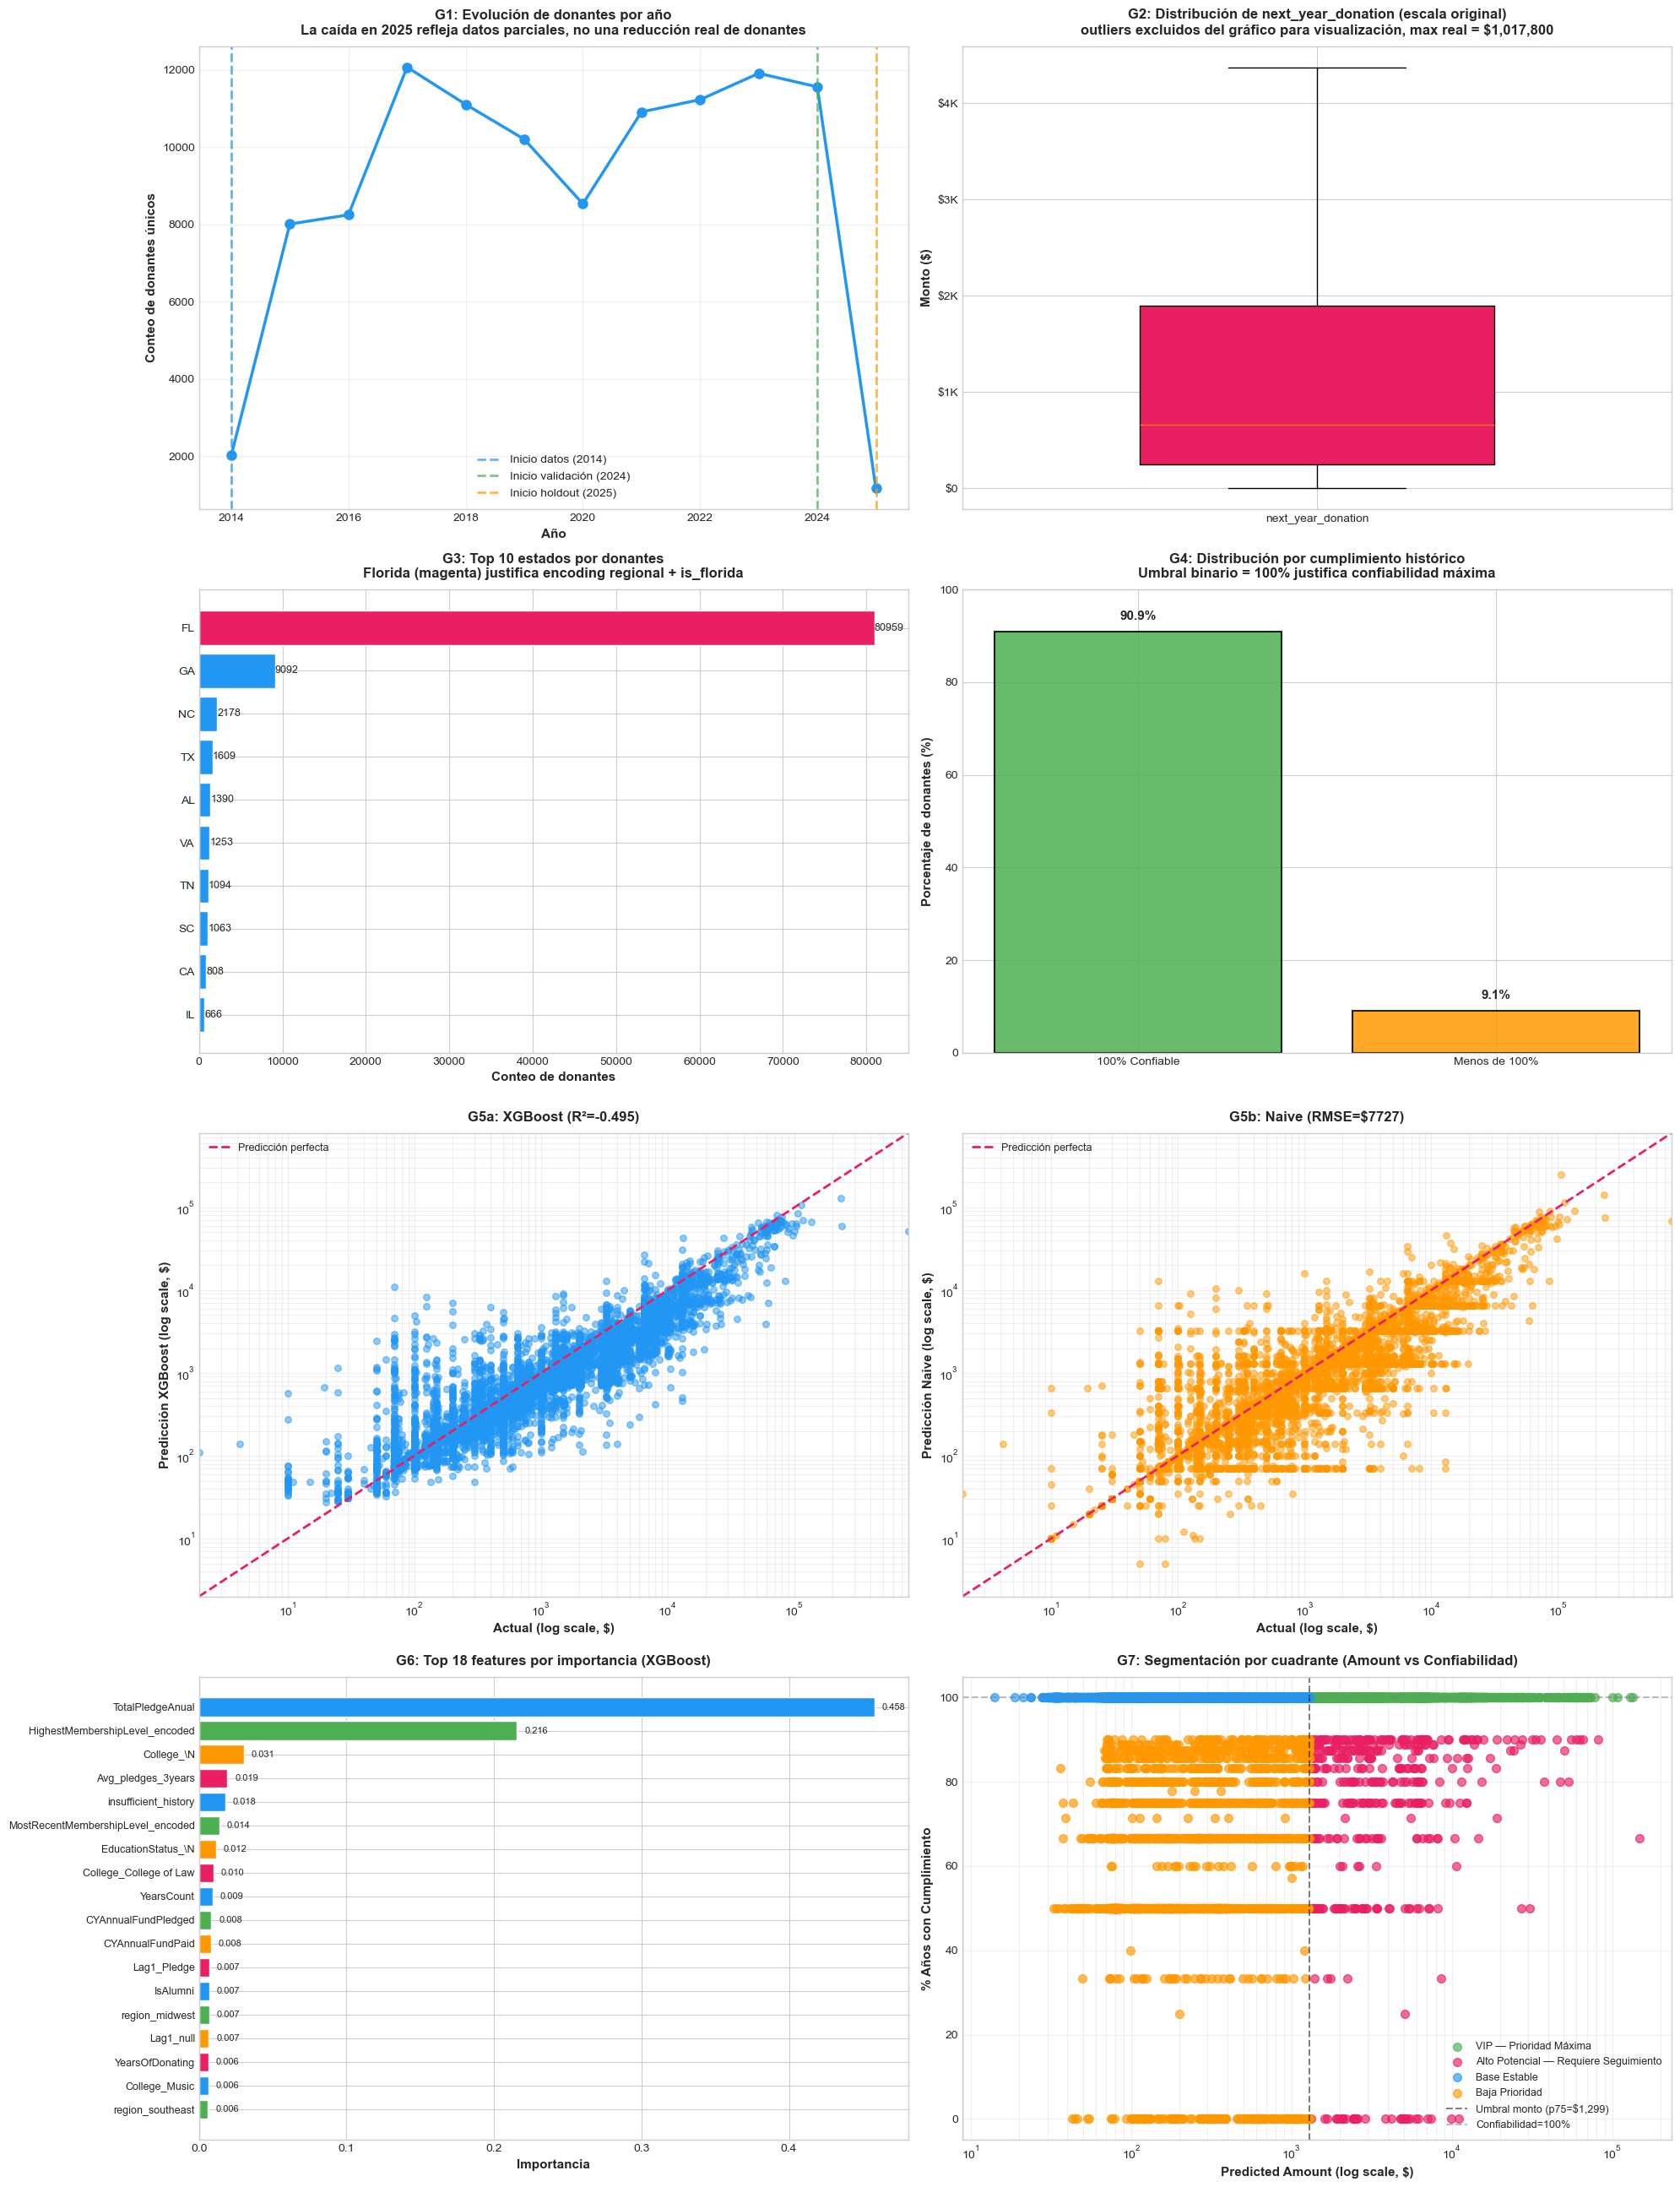


✓ G2 y G5 ajustados: nota de outliers + ejes comparables


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'train': '#2196F3', 'val': '#4CAF50', 'test': '#FF9800', 'highlight': '#E91E63'}

plt.rcParams['figure.figsize'] = (20, 24)
fig = plt.figure(figsize=(20, 26))

# ==================== G1: Conteo de donantes por año ====================
ax1 = plt.subplot(4, 2, 1)
donors_by_year = df_processed.groupby('DriveYear')['FanID'].nunique()
ax1.plot(donors_by_year.index, donors_by_year.values, marker='o', linewidth=2.5, markersize=8, color=COLORS['train'])
ax1.axvline(x=2014, color=COLORS['train'], linestyle='--', linewidth=2, label='Inicio datos (2014)', alpha=0.7)
ax1.axvline(x=2024, color=COLORS['val'], linestyle='--', linewidth=2, label='Inicio validación (2024)', alpha=0.7)
ax1.axvline(x=2025, color=COLORS['test'], linestyle='--', linewidth=2, label='Inicio holdout (2025)', alpha=0.7)
ax1.set_xlabel('Año', fontsize=11, fontweight='bold')
ax1.set_ylabel('Conteo de donantes únicos', fontsize=11, fontweight='bold')
ax1.set_title(
    'G1: Evolución de donantes por año\n'
    'La caída en 2025 refleja datos parciales, no una reducción real de donantes',
    fontsize=12, fontweight='bold', pad=10
)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ==================== G2: Boxplot de next_year_donation en escala original ====================
ax2 = plt.subplot(4, 2, 2)
df_orig = df_processed[df_processed['next_year_donation'] > 0].copy()
df_orig['next_year_donation_original'] = np.expm1(df_orig['next_year_donation'])
real_max = df_orig['next_year_donation_original'].max()
bp = ax2.boxplot([df_orig['next_year_donation_original']], vert=True, widths=0.5, patch_artist=True,
                   showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['highlight'])
ax2.set_ylabel('Monto ($)', fontsize=11, fontweight='bold')
ax2.set_title(
    'G2: Distribución de next_year_donation (escala original)\n'
    'outliers excluidos del gráfico para visualización, max real = ${:,.0f}'.format(real_max),
    fontsize=12,
    fontweight='bold',
    pad=10
)
ax2.set_xticklabels(['next_year_donation'])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K' if x >= 1000 else f'${x:.0f}'))

# ==================== G3: Top 10 estados (Florida diferente color) ====================
ax3 = plt.subplot(4, 2, 3)
state_counts = df_processed['state'].value_counts().head(10)
colors = [COLORS['highlight'] if state == 'FL' else COLORS['train'] for state in state_counts.index]
ax3.barh(range(len(state_counts)), state_counts.values, color=colors)
ax3.set_yticks(range(len(state_counts)))
ax3.set_yticklabels(state_counts.index)
ax3.set_xlabel('Conteo de donantes', fontsize=11, fontweight='bold')
ax3.set_title('G3: Top 10 estados por donantes\nFlorida (magenta) justifica encoding regional + is_florida', 
              fontsize=12, fontweight='bold', pad=10)
ax3.invert_yaxis()
for i, v in enumerate(state_counts.values):
    ax3.text(v + 30, i, str(v), va='center', fontsize=9)

# ==================== G4: % de donantes por cumplimiento ====================
ax4 = plt.subplot(4, 2, 4)
reliability_dist = fan_reliability['pct_years_met_commitment'].copy()
perfect_pct = (reliability_dist == 100).mean() * 100
imperfect_pct = (reliability_dist < 100).mean() * 100
categories = ['100% Confiable', 'Menos de 100%']
values = [perfect_pct, imperfect_pct]
colors_bar = [COLORS['val'], COLORS['test']]
bars = ax4.bar(categories, values, color=colors_bar, alpha=0.85, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Porcentaje de donantes (%)', fontsize=11, fontweight='bold')
ax4.set_title('G4: Distribución por cumplimiento histórico\nUmbral binario = 100% justifica confiabilidad máxima', 
              fontsize=12, fontweight='bold', pad=10)
ax4.set_ylim([0, 100])
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ==================== G5: Scatterplots lado a lado (XGBoost vs Naive) ====================
y_true_original = np.expm1(y_val.values)
y_pred_xgb = np.expm1(xgb_reg.predict(X_val))
y_naive = X_val['TotalPledgeAnual'].to_numpy(dtype=float)

valid_idx = (y_true_original > 0) & (y_pred_xgb > 0) & np.isfinite(y_true_original) & np.isfinite(y_pred_xgb)
valid_naive = (y_true_original > 0) & (y_naive > 0) & np.isfinite(y_true_original) & np.isfinite(y_naive)

common_axis_values = np.concatenate([
    y_true_original[valid_idx],
    y_pred_xgb[valid_idx],
    y_true_original[valid_naive],
    y_naive[valid_naive]
])
common_min = max(1.0, common_axis_values.min())
common_max = common_axis_values.max()

ax5 = plt.subplot(4, 2, 5)
ax5.scatter(y_true_original[valid_idx], y_pred_xgb[valid_idx], alpha=0.5, s=30, color=COLORS['train'])
ax5.plot([common_min, common_max], [common_min, common_max], color=COLORS['highlight'], linestyle='--', lw=2, label='Predicción perfecta')
ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.set_xlim(common_min, common_max)
ax5.set_ylim(common_min, common_max)
ax5.set_xlabel('Actual (log scale, $)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Predicción XGBoost (log scale, $)', fontsize=11, fontweight='bold')
ax5.set_title(f'G5a: XGBoost (R²={r2:.3f})', fontsize=12, fontweight='bold', pad=10)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, which='both')

ax6 = plt.subplot(4, 2, 6)
ax6.scatter(y_true_original[valid_naive], y_naive[valid_naive], alpha=0.5, s=30, color=COLORS['test'])
ax6.plot([common_min, common_max], [common_min, common_max], color=COLORS['highlight'], linestyle='--', lw=2, label='Predicción perfecta')
ax6.set_xscale('log')
ax6.set_yscale('log')
ax6.set_xlim(common_min, common_max)
ax6.set_ylim(common_min, common_max)
ax6.set_xlabel('Actual (log scale, $)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Predicción Naive (log scale, $)', fontsize=11, fontweight='bold')
ax6.set_title(f'G5b: Naive (RMSE=${rmse_naive:.0f})', fontsize=12, fontweight='bold', pad=10)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, which='both')

# ==================== G6: Top features por importancia ====================
ax7 = plt.subplot(4, 2, 7)
fi_sorted = fi.head(18)
colors_palette = [COLORS['train'], COLORS['val'], COLORS['test'], COLORS['highlight']]
colors_fi = [colors_palette[i % len(colors_palette)] for i in range(len(fi_sorted))]
ax7.barh(range(len(fi_sorted)), fi_sorted['importance'].values, color=colors_fi)
ax7.set_yticks(range(len(fi_sorted)))
ax7.set_yticklabels(fi_sorted['feature'].values, fontsize=9)
ax7.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax7.set_title('G6: Top 18 features por importancia (XGBoost)', fontsize=12, fontweight='bold', pad=10)
ax7.invert_yaxis()
for i, v in enumerate(fi_sorted['importance'].values):
    ax7.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

# ==================== G7: Scatter predicted vs confiabilidad por cuadrante ====================
ax8 = plt.subplot(4, 2, 8)
quadrant_colors = {
    'VIP — Prioridad Máxima': COLORS['val'],
    'Alto Potencial — Requiere Seguimiento': COLORS['highlight'],
    'Base Estable': COLORS['train'],
    'Baja Prioridad': COLORS['test']
}
for quadrant, color in quadrant_colors.items():
    mask = segmentation_table['quadrant'] == quadrant
    data = segmentation_table[mask]
    ax8.scatter(data['predicted_amount'], data['pct_years_met_commitment'].fillna(0), 
               alpha=0.65, s=50, label=quadrant, color=color)
ax8.axvline(x=amount_cutoff, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Umbral monto (p75=${amount_cutoff:,.0f})')
ax8.axhline(y=100, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Confiabilidad=100%')
ax8.set_xscale('log')
ax8.set_xlabel('Predicted Amount (log scale, $)', fontsize=11, fontweight='bold')
ax8.set_ylabel('% Años con Cumplimiento', fontsize=11, fontweight='bold')
ax8.set_title('G7: Segmentación por cuadrante (Amount vs Confiabilidad)', fontsize=12, fontweight='bold', pad=10)
ax8.legend(fontsize=9, loc='best')
ax8.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('segmentation_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ G2 y G5 ajustados: nota de outliers + ejes comparables")

# AFTER EXECUTIVE SUMMARY 

# winrate of FSU in Football that season
# infation date / federalreserve interest rate (change) / interest rate inter banks -> ECONOMIC FACTORS
# clasificacion de personas que van a reducir su pledge